In [11]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
import numpy as np

# Load dataset
df = pd.read_csv('train.csv')

# Select feature and target
X = df[['Age']]
y = df['Survived']

# Handle missing values
X = X.copy()
X['Age'] = X['Age'].fillna(X['Age'].mean())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Function to plot KDE and QQ plots
def plot_transform(transformer, X):

    X_transformed = transformer.fit_transform(X[['Age']])
    X_transformed = np.asarray(X_transformed).reshape(-1)

    plt.figure(figsize=(12,4))

    plt.subplot(121)
    sns.kdeplot(X_transformed, fill=True)
    plt.title('KDE Plot')

    plt.subplot(122)
    stats.probplot(X_transformed,
                   dist='norm',
                   plot=plt)
    plt.title('QQ Plot')

    plt.show()

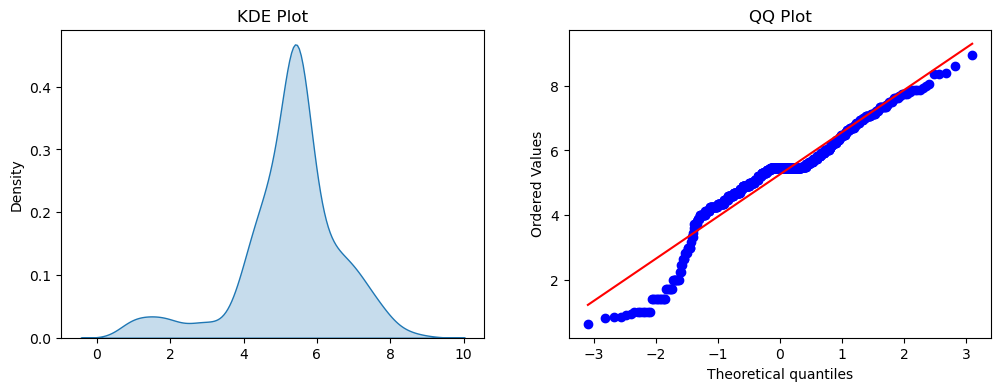

In [ ]:
sqrt_transformer = FunctionTransformer(np.sqrt)

plot_transform(sqrt_transformer, X_train)i

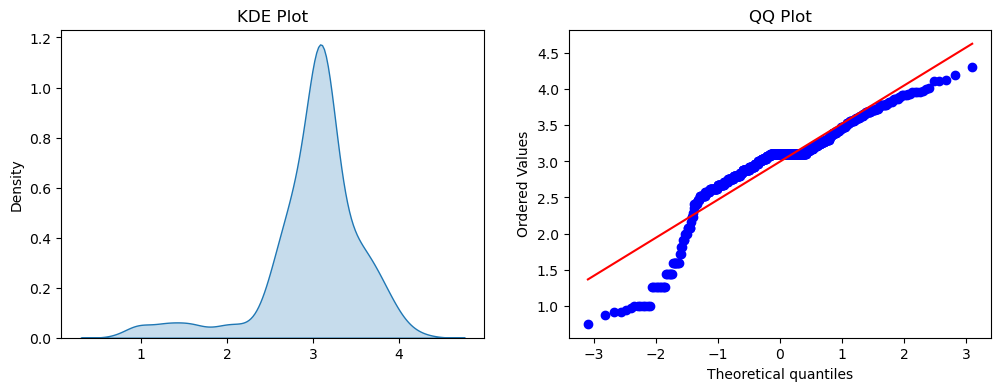

In [10]:
cbrt_transformer = FunctionTransformer(np.cbrt)

plot_transform(cbrt_transformer, X_train)